# Insula–DMN Focused CPM

This notebook focuses on testing whether connectivity between insula and DMN predicts a behavioral variable.

In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Imports OK")


Imports OK


In [2]:

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
PHENO_DIR = DATA_DIR / "phenotypes"

connectomes = np.load(PROCESSED_DIR / "simulated_connectomes.npy")
pheno = pd.read_csv(PHENO_DIR / "simulated_trait_anxiety.csv")

print(connectomes.shape)
print(pheno.head())


(80, 20, 20)
  subject_id  trait_anxiety
0    sub-001      48.047171
1    sub-002      34.600159
2    sub-003      52.504512
3    sub-004      54.405647
4    sub-005      25.489648


In [3]:

TARGET_COLUMN = "trait_anxiety"

y = pd.to_numeric(pheno[TARGET_COLUMN], errors="coerce").values
valid = np.isfinite(y)

connectomes = connectomes[valid]
y = y[valid]

print("Subjects:", len(y))


Subjects: 80


In [4]:

insula_idx = [0,1]
dmn_idx = [2,3,4]

def extract_insula_dmn_features(conn):
    return np.array([conn[i,j] for i in insula_idx for j in dmn_idx])

X = np.array([extract_insula_dmn_features(c) for c in connectomes])
print("Feature shape:", X.shape)


Feature shape: (80, 6)


In [5]:

loo = LeaveOneOut()
y_pred = np.zeros(len(y))

for train_idx, test_idx in loo.split(X):
    model = LinearRegression()
    model.fit(X[train_idx], y[train_idx])
    y_pred[test_idx] = model.predict(X[test_idx])


In [6]:

r, p = pearsonr(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"r = {r:.3f}, p = {p:.4f}")
print(f"MAE = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")


r = 0.014, p = 0.9000
MAE = 6.691
RMSE = 7.996


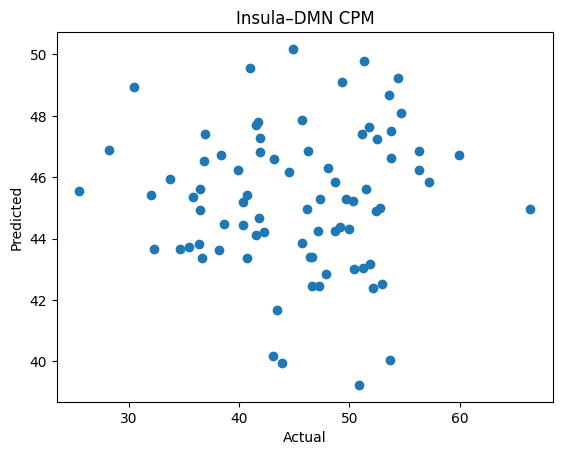

In [7]:

plt.scatter(y, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Insula–DMN CPM")
plt.show()
